#2 Getting Started with Image Processing with Python.

Introduction to Python Imaging Library(PIL)

2.1 Exercise - 1:

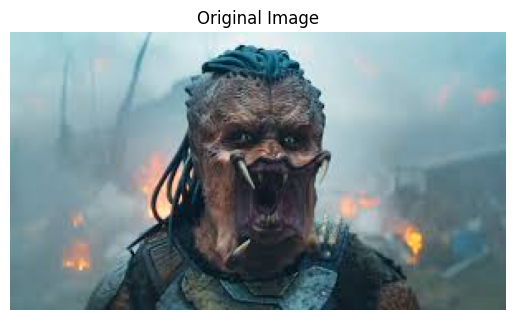

In [3]:
# 1. Read and Display Image
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

img = Image.open("//content/drive/MyDrive/Ai ML/week1/images.jpg")
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()


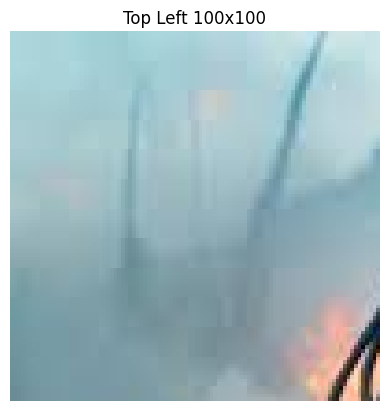

In [5]:
# 2. Display top-left 100x100 pixels
img = np.array(Image.open("/content/drive/MyDrive/Ai ML/week1/images.jpg"))
corner = img[:100, :100]

plt.imshow(corner)
plt.title("Top Left 100x100")
plt.axis("off")
plt.show()


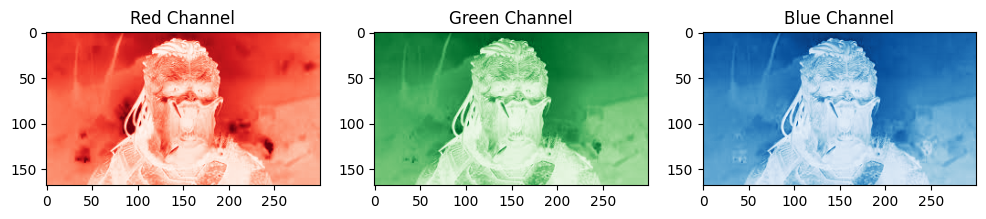

In [6]:
# 3. Show RGB Channels
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img = np.array(Image.open("/content/drive/MyDrive/Ai ML/week1/images.jpg"))

R = img[:,:,0]
G = img[:,:,1]
B = img[:,:,2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap="Reds")
plt.title("Red Channel")

plt.subplot(1,3,2)
plt.imshow(G, cmap="Greens")
plt.title("Green Channel")

plt.subplot(1,3,3)
plt.imshow(B, cmap="Blues")
plt.title("Blue Channel")

plt.show()


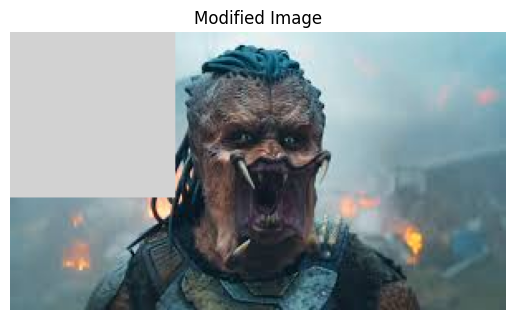

In [7]:
# 4. Modify top 100x100 pixels to value 210

img = np.array(Image.open("/content/drive/MyDrive/Ai ML/week1/images.jpg"))

img[:100,:100] = 210

plt.imshow(img)
plt.title("Modified Image")
plt.axis("off")
plt.show()


#2.2 Exercise - 2:

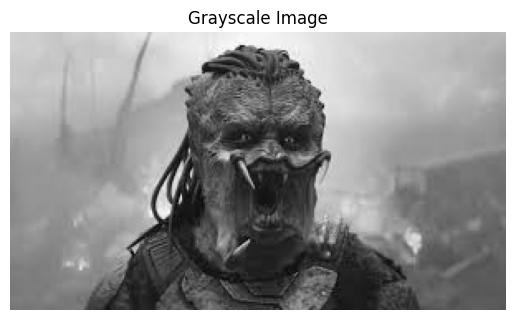

In [8]:
# 1. Load and Display Grayscale Image
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/drive/MyDrive/Ai ML/week1/images.jpg").convert("L")

plt.imshow(img, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()


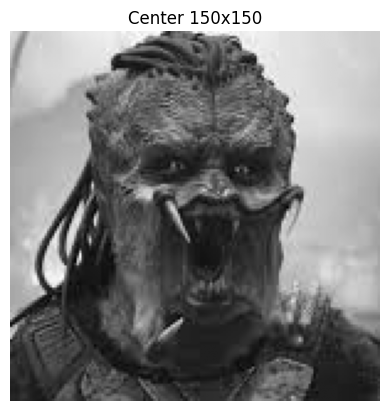

In [9]:
# 2. Extract Middle 150 Pixels
img = np.array(Image.open("/content/drive/MyDrive/Ai ML/week1/images.jpg").convert("L"))

h,w = img.shape
center = img[h//2-75:h//2+75, w//2-75:w//2+75]

plt.imshow(center, cmap="gray")
plt.title("Center 150x150")
plt.axis("off")
plt.show()


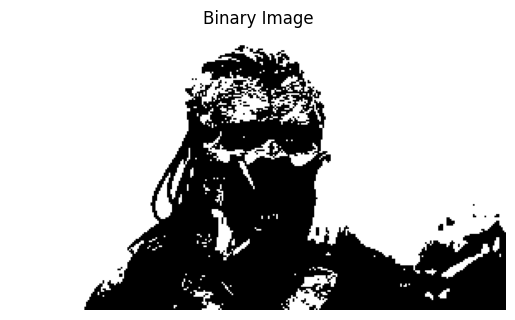

In [10]:
# 3. Apply Threshold
img = np.array(Image.open("/content/drive/MyDrive/Ai ML/week1/images.jpg").convert("L"))

binary = np.where(img < 100, 0, 255)

plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")
plt.show()


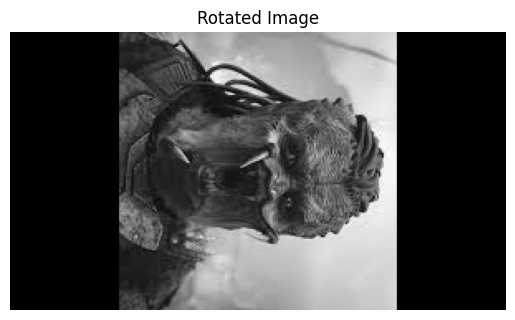

In [11]:
# 4. Rotate Image 90 Degrees Clockwise
img = Image.open("/content/drive/MyDrive/Ai ML/week1/images.jpg").convert("L")

rotated = img.rotate(-90)

plt.imshow(rotated, cmap="gray")
plt.title("Rotated Image")
plt.axis("off")
plt.show()


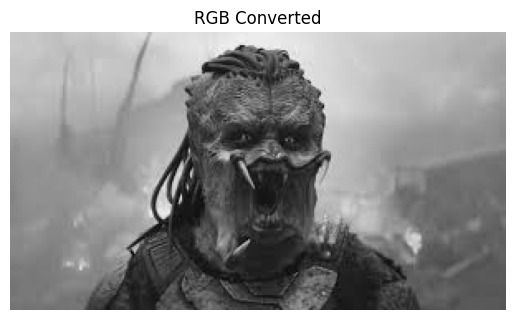

In [12]:
# 5. Convert Grayscale to RGB
gray = np.array(Image.open("/content/drive/MyDrive/Ai ML/week1/images.jpg").convert("L"))

rgb = np.stack((gray,)*3, axis=-1)

plt.imshow(rgb)
plt.title("RGB Converted")
plt.axis("off")
plt.show()


#3 Image Compression and Decompression using PCA.

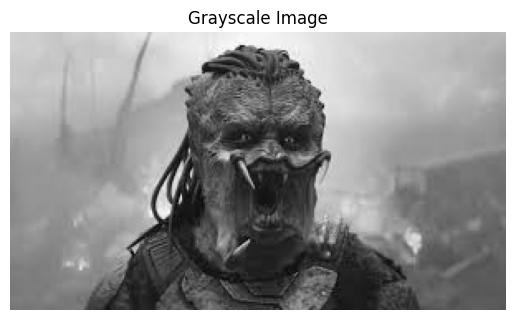

In [13]:
# 1. Load Image and Convert to Grayscale
img = Image.open("/content/drive/MyDrive/Ai ML/week1/images.jpg").convert("L")
img = np.array(img)

plt.imshow(img, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()


In [18]:
# Standardize Data
mean = np.mean(img)
std = np.std(img)

standardized = (img - mean) / std

In [17]:
# Covariance Matrix
cov_matrix = np.cov(standardized)

In [16]:
# 2 Eigen Decomposition
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

In [19]:
# Sort Eigenvalues
idx = np.argsort(eigen_values)[::-1]

eigen_values = eigen_values[idx]
eigen_vectors = eigen_vectors[:,idx]

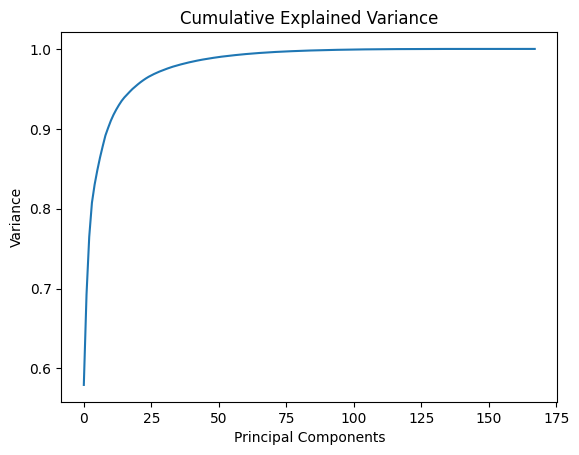

In [20]:
# Explained Variance Plot
explained = eigen_values / np.sum(eigen_values)
cumulative = np.cumsum(explained)

plt.plot(cumulative)
plt.title("Cumulative Explained Variance")
plt.xlabel("Principal Components")
plt.ylabel("Variance")
plt.show()

In [21]:
# Select Top k Components
k = 50
pcs = eigen_vectors[:,:k]

In [22]:
# 3 Transform Image
compressed = np.dot(pcs.T, standardized)

In [23]:
# Reconstruct Image
reconstructed = np.dot(pcs, compressed)

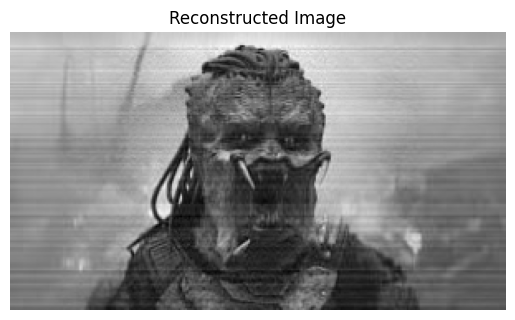

In [24]:
# Display Reconstructed Image
import matplotlib.pyplot as plt

plt.imshow(reconstructed, cmap="gray")
plt.title("Reconstructed Image")
plt.axis("off")
plt.show()

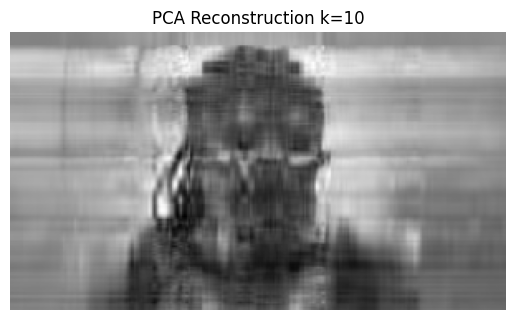

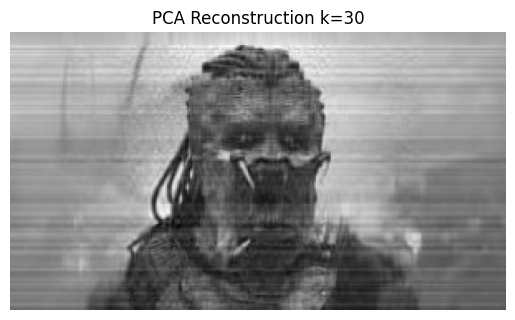

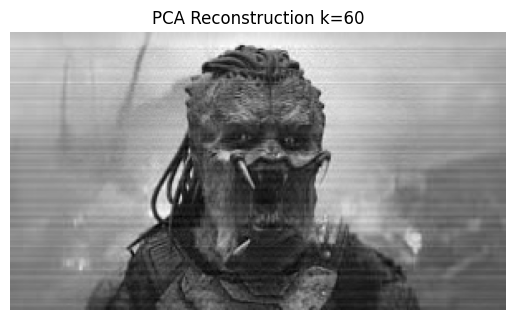

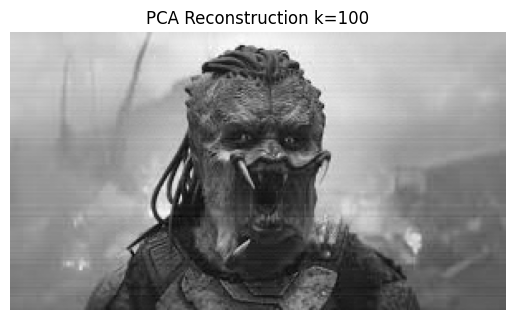

In [25]:
# Experiment with different PC values
import matplotlib.pyplot as plt
ks=[10,30,60,100]

for k in ks:
    pcs=eigen_vectors[:,:k]
    comp=np.dot(pcs.T,standardized)
    rec=np.dot(pcs,comp)

    plt.imshow(rec,cmap='gray')
    plt.title(f"PCA Reconstruction k={k}")
    plt.axis("off")
    plt.show()